
# Tracking Multi-Character Emotional Arcs using LabMT

This notebook demonstrates a Digital Humanities pipeline to track single and multi-character emotional arcs in a shory. We use the **labMT sentiment dictionary** (happiness scores 1–9)
and **spaCy dependency parsing** to track character-specific emotional arcs.

**Dependencies**: matplotlib, numpy, spacy (en_core_web_sm)

---

---
## Kurt Vonnegut's "Shape of Stories"

> *"There is no reason why the simple shapes of stories can't be fed into computers."*
> — Kurt Vonnegut, rejected anthropology thesis (1947)

Vonnegut proposed that every story has a **shape** — a curve of fortune over time.
The labMT dictionary lets us **measure** this shape by scoring each word's happiness (1–9).


## 0. Setup: Load labMT English Lexicon

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import spacy
from collections import defaultdict
import string  # New import


# ROOT: current working directory of the notebook.
# We assume the notebook and 'labMT-english.csv' live in the same folder.
ROOT = Path.cwd()

# Full path to the single labMT English CSV file.
# The file is expected to have two columns: word,score
LABMT_PATH = Path("labMT-english.csv")

# labmt: dictionary mapping each word (str) to its happiness score (float).
labmt = {}

# Create a translation table to remove punctuation
translator = str.maketrans('', '', string.punctuation)

# Open the labMT file and read it line by line.
with open(LABMT_PATH, encoding="utf-8") as f:
    for line in f:
        # Remove leading/trailing whitespace and newline characters.
        line = line.strip()
        # Skip empty lines.
        if not line:
            continue

        # Split the line into columns.
        # If your file is tab-separated instead of comma-separated,
        # change "," to "\t" here.
        parts = line.split(",")

        # We expect at least two columns: word and score.
        if len(parts) < 2:
            continue

        # First column: word form.
        # Strip whitespace and lowercase so lookups are case-insensitive.
        word = parts[0].strip().lower()

        # Second column: numeric score as string.
        score_str = parts[1].strip()

        # Only add entries that have both a non-empty word and score.
        if word and score_str:
            # Convert score string to float and store in the dictionary.
            labmt[word] = float(score_str)



# --- Quick sanity checks for the loaded dictionary ---

# 1) Print basic information about the dictionary.
print(f"labMT loaded: {len(labmt)} words")

# 2) Print the first 10 (word, score) pairs for inspection.
#    We sort by word to make the output deterministic and easier to read.
first_10_items = list(sorted(labmt.items(), key=lambda x: x[0]))[:10]
print("First 10 entries in labmt (word -> score):")
for w, s in first_10_items:
    print(f"  {w}: {s}")


labMT loaded: 10219 words
First 10 entries in labmt (word -> score):
  #epicpetwars: 4.54
  #fact: 5.3
  #fail: 2.62
  #fb: 5.12
  #ff: 4.64
  #followfriday: 5.24
  #formspringme: 4.54
  #haiti: 4.38
  #idothat2: 4.56
  #in2010: 4.9


/Users/wupeizhen/chap2experim/venv/lib/python3.11/site-packages/spacy/cli/info.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Sentiment Analysis Functions using labMT dictionary
This next cell defines the core functions for sentiment analysis using the `labMT` dictionary:

*   **`STOP_LENS`**: This tuple `(4.0, 6.0)` specifies a 'neutral' interval for sentiment scores. Words whose happiness scores fall within this range are considered neutral and are excluded from the analysis. This helps focus on words with more distinct positive or negative connotations.

*   **`happiness(text: str)`**: This function calculates the average happiness score for a given text. It processes the text by lowercasing words, removing punctuation, and then looks up each word in the `labMT` dictionary. Only words with scores *outside* the `STOP_LENS` interval contribute to the average. If no contributing words are found, it returns a default neutral score of 5.0.

*   **`word_contributions(text: str)`**: This helper function provides a detailed breakdown of which words actually contribute to the `happiness` score. It applies the same filtering logic as the `happiness` function but instead returns a list of `(word, score)` pairs for all words that are found in `labMT` and have scores outside the neutral `STOP_LENS`.

In [2]:
# STOP_LENS defines the "neutral" score interval.
# Words whose scores fall inside this range will be excluded from analysis.
# This follows the Hedonometer / labMT convention.
STOP_LENS = (4.0, 6.0)  # neutral band; we keep only clearly positive/negative words


def happiness(text: str) -> float:
    """
    Compute the average labMT happiness score for a given text.

    Steps:
    1. Lowercase and split the text into whitespace-separated tokens.
    2. For each word, if it appears in labmt and its score is
       outside the neutral interval [STOP_LENS[0], STOP_LENS[1]],
       include its score in the list.
    3. Return the mean of the remaining scores.
       If there are no contributing words, return 5.0 as a neutral default.
    """
    # Lowercase and tokenize the text into words.
    clean_text = text.translate(translator).lower()
    words = clean_text.split()

    # Collect scores for words that:
    # - exist in the labmt dictionary, and
    # - are outside the neutral stop-lens interval.
    scores = [
        labmt[w]
        for w in words
        if w in labmt and not (STOP_LENS[0] <= labmt[w] <= STOP_LENS[1])
    ]

    # If we have at least one contributing word, return the mean score.
    # Otherwise, fall back to a neutral value of 5.0.
    return np.mean(scores) if scores else 5.0


def word_contributions(text: str):
    """
    Return the list of (word, score) pairs that contribute to the happiness score.

    This function mirrors the filtering logic in `happiness`, but instead of
    collapsing everything into a single mean value, it exposes which words
    actually contribute and what their individual scores are.

    Returns:
        List of (word, score) tuples for all words in `text` that:
        - are found in the labmt dictionary, and
        - have scores outside the neutral STOP_LENS interval.
    """
    # Remove punctuation and lowercase before splitting
    clean_text = text.translate(translator).lower()
    words = clean_text.split()

    return [
        (w, labmt[w])
        for w in words
        if w in labmt and not (STOP_LENS[0] <= labmt[w] <= STOP_LENS[1])
    ]

---
## 2. Single-Character Story

A simple 5-sentence story about **Emma**. One character, clear emotional arc.

In [3]:
emma_story = [
    "Emma started her journey with hope and excitement in her heart.",          # S1: hopeful start
    "She found a beautiful garden full of laughter and joy.",                    # S2: happiness peak
    "But a terrible storm destroyed everything she loved and brought pain.",     # S3: setback
    "Emma mastered up courage to deal with the storm.",   # S4: perseverance
    "Finally she achieved a glorious victory and celebrated with great pride.",  # S5: triumph
]

# Compute happiness per sentence
emma_scores = [happiness(s) for s in emma_story]
emma_labels = ["S1: Hope", "S2: Joy", "S3: Storm", "S4: Courage", "S5: Victory"]

# Show word-level breakdown
for i, s in enumerate(emma_story):
    contribs = word_contributions(s)
    words_str = ", ".join(f"{w}({v:.1f})" for w, v in contribs)
    print(f"S{i+1} [h={emma_scores[i]:.2f}]: {words_str}")

S1 [h=7.34]: journey(7.1), hope(7.4), excitement(7.6), heart(7.2)
S2 [h=7.25]: she(6.2), found(6.5), beautiful(7.9), garden(7.2), full(6.2), laughter(8.5), joy(8.2)
S3 [h=4.22]: terrible(2.8), destroyed(2.0), she(6.2), loved(8.0), pain(2.1)
S4 [h=6.64]: up(6.1), courage(7.5), deal(6.3)
S5 [h=7.38]: she(6.2), achieved(7.6), glorious(7.7), victory(8.0), celebrated(7.8), great(7.9), pride(6.5)


Then we visualize the computed happiness scores for Emma's story. It uses `matplotlib` to plot the sentiment arc over the sentences, highlighting the changes in happiness. A neutral line at 5.0 is added for reference, and each data point is annotated with its corresponding sentence label and score.

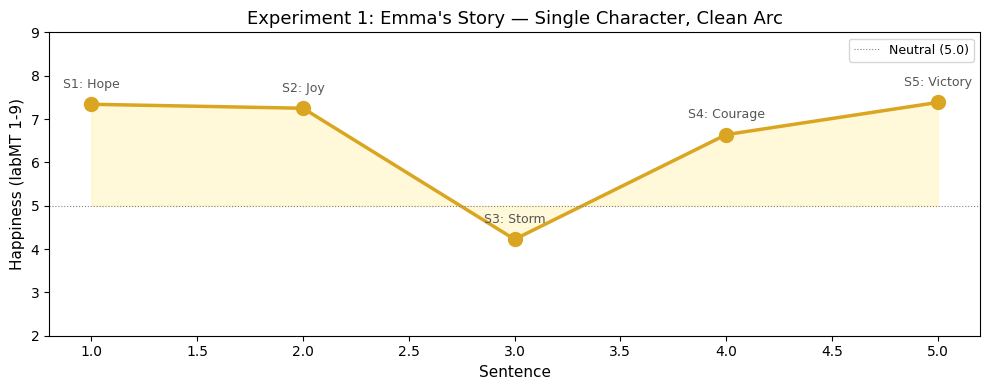


✅ The traditional lexicon method produces a clear Vonnegut arc for a single character.
   But what happens when TWO characters share the same sentences?


In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, 6), emma_scores, "o-", color="goldenrod", linewidth=2.5, markersize=10)
ax.fill_between(range(1, 6), emma_scores, 5.0, alpha=0.15, color="gold")
ax.axhline(5.0, color="gray", linestyle=":", linewidth=0.8, label="Neutral (5.0)")
for i, (lbl, sc) in enumerate(zip(emma_labels, emma_scores)):
    ax.annotate(lbl, (i+1, sc), textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=9, color="#555")
ax.set_xlabel("Sentence", fontsize=11)
ax.set_ylabel("Happiness (labMT 1-9)", fontsize=11)
ax.set_title("Experiment 1: Emma's Story — Single Character, Clean Arc", fontsize=13)
ax.set_ylim(2, 9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n✅ The traditional lexicon method produces a clear Vonnegut arc for a single character.")
print("   But what happens when TWO characters share the same sentences?")

---
## 3.  Multi-Character Challenge

Now introduce **Leo** and **Mia** alongside Emma.

S1 [h=7.13]: adventure(7.3), together(6.8), shared(6.8), excitement(7.6)
S2 [h=7.14]: found(6.5), safe(7.0), great(7.9), relief(6.9), hope(7.4), home(7.1)
S3 [h=4.52]: celebrated(7.8), courage(7.5), terrible(2.8), fear(2.3), agony(2.2)
S4 [h=6.74]: she(6.2), forward(6.1), brilliant(7.7), determination(7.0)
S5 [h=3.08]: fell(3.2), dark(3.8), despair(2.8), suffered(2.2), alone(3.3)
S6 [h=7.56]: reached(6.1), glorious(7.7), laughed(8.3), joy(8.2)
S7 [h=3.49]: lost(2.8), forever(6.5), cruel(1.8), hopeless(2.6), darkness(3.8)


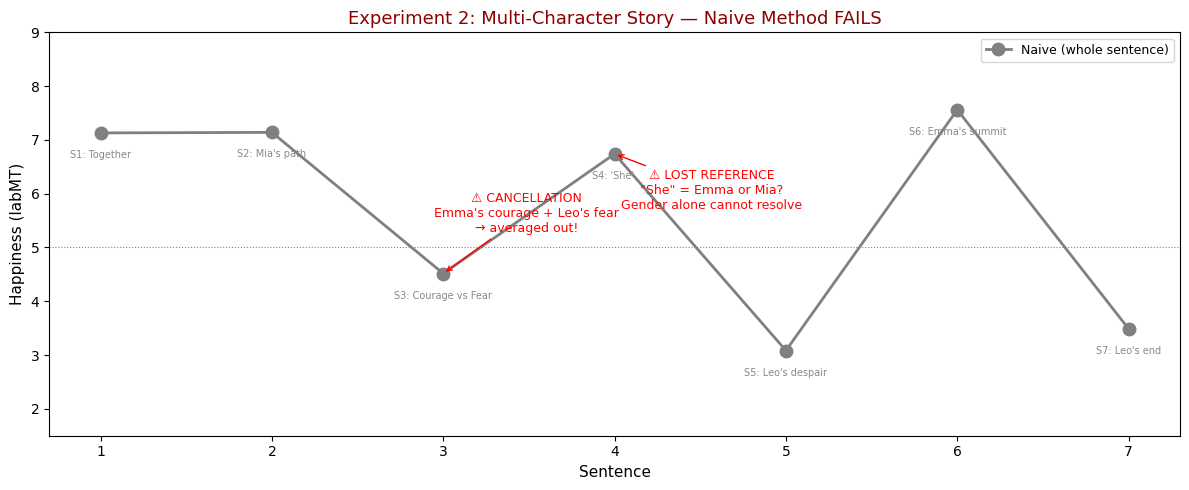


❌ Two failure modes:
   1. Sentiment CANCELLATION — S3 averages courage + fear → flat
   2. Pronoun LOSS — S4 'She' can't be assigned to Emma → data gap

   Simple filtering causes NARRATIVE TENSION ERASURE.


In [5]:
multi_story = [
    "Emma, Leo and Mia began their adventure together with shared excitement.",      # S1: all three positive
    "Mia found a safe path, felt great relief and hope, and went home afterwards.",                            # S2: Mia positive (last female = Mia)
    "While Emma celebrated her courage, Leo was consumed by terrible fear and agony.",  # S3: CONFLICT (last female = Emma)
    "She pressed forward with brilliant determination.",                                # S4: pronoun — Mia or Emma?
    "Leo fell into a dark pit of despair and suffered alone.",                          # S5: Leo negative
    "Emma reached the glorious summit and laughed with triumphant joy.",                # S6: Emma triumph
    "Leo was lost forever in the cruel and hopeless darkness.",                         # S7: Leo tragic end
]

sentence_labels = [
    "S1: Together", "S2: Mia's path", "S3: Courage vs Fear",
    "S4: 'She' ", "S5: Leo's despair", "S6: Emma's summit", "S7: Leo's end"
]

# Naive approach: just compute happiness per sentence
naive_scores = [happiness(s) for s in multi_story]

for i, (s, sc) in enumerate(zip(multi_story, naive_scores)):
    contribs = word_contributions(s)
    print(f"S{i+1} [h={sc:.2f}]: {', '.join(f'{w}({v:.1f})' for w, v in contribs)}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, 8), naive_scores, "o-", color="gray", linewidth=2, markersize=9, label="Naive (whole sentence)")
ax.axhline(5.0, color="gray", linestyle=":", linewidth=0.8)

# Highlight the two failure points
ax.annotate("⚠️ CANCELLATION\nEmma's courage + Leo's fear\n→ averaged out!",
            (3, naive_scores[2]), textcoords="offset points", xytext=(60, 30),
            fontsize=9, color="red", ha="center",
            arrowprops=dict(arrowstyle="->", color="red"))
ax.annotate('⚠️ LOST REFERENCE\n"She" = Emma or Mia?\nGender alone cannot resolve',
            (4, naive_scores[3]), textcoords="offset points", xytext=(70, -40),
            fontsize=9, color="red", ha="center",
            arrowprops=dict(arrowstyle="->", color="red"))

for i, lbl in enumerate(sentence_labels):
    ax.annotate(lbl, (i+1, naive_scores[i]), textcoords="offset points",
                xytext=(0, -18), ha="center", fontsize=7, color="#888")

ax.set_xlabel("Sentence", fontsize=11)
ax.set_ylabel("Happiness (labMT)", fontsize=11)
ax.set_title("Experiment 2: Multi-Character Story — Naive Method FAILS", fontsize=13, color="darkred")
ax.set_ylim(1.5, 9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n❌ Two failure modes:")
print("   1. Sentiment CANCELLATION — S3 averages courage + fear → flat")
print("   2. Pronoun LOSS — S4 'She' can't be assigned to Emma → data gap")
print("\n   Simple filtering causes NARRATIVE TENSION ERASURE.")

To find which sentences talk about which characters, this cell defines a logic to assign each sentence from the `multi_story` to specific characters based on explicit mentions within the sentence.

Here's how it works:

1.  **Character List**: It starts with a predefined set of `character_names` (Emma, Leo, Mia).
2.  **Sentence Iteration**: It goes through each sentence in the `multi_story` list.
3.  **Mention Detection**: For each sentence, it checks if any of the `character_names` are explicitly mentioned (case-insensitively).
4.  **Assignment Logic**:
    *   **If one or more characters are mentioned**: The sentence is assigned to *each* character whose name appears in that sentence.
    *   **If no characters are mentioned**: The sentence is assigned to an 'others' category.


In [6]:
# Define the set of character names to track
character_names = {"Emma", "Leo", "Mia"}

# Initialize a dictionary to store sentence assignments for each character and 'others'
sentence_assignments = {
    "Emma": [],   # List to store (sentence_label, sentence_text) for Emma
    "Leo": [],    # List to store (sentence_label, sentence_text) for Leo
    "Mia": [],    # List to store (sentence_label, sentence_text) for Mia
    "others": []  # List to store (sentence_label, sentence_text) for others
}

# Iterate through each sentence in the multi_story list with its index
for i, sentence in enumerate(multi_story):
    # Initialize a set to keep track of characters mentioned in the current sentence
    mentioned_chars = set()
    # Convert the sentence to lowercase for case-insensitive matching
    sentence_lower = sentence.lower()

    # Check if each character's name appears in the current sentence
    for char in character_names:
        if char.lower() in sentence_lower:
            mentioned_chars.add(char) # Add character to the set if mentioned

    # Apply the new logic for assignment:
    # If any characters are mentioned in the sentence
    if mentioned_chars:
        # Assign the sentence to each mentioned character
        for char in mentioned_chars:
            sentence_assignments[char].append((f"S{i+1}", sentence))
    # If no characters are mentioned
    else:
        # Assign the sentence to the 'others' category
        sentence_assignments["others"].append((f"S{i+1}", sentence))

# Print the final assignments for each character and 'others'
print("Sentence assignments based on explicit character mentions (new logic):")
for char, s_list_of_tuples in sentence_assignments.items():
    if s_list_of_tuples:
        print(f"  {char}:")
        for label, sent_text in s_list_of_tuples:
            print(f"    - {label}: \"{sent_text}\"")
    else:
        print(f"  {char}: None")

print("\nNote: Sentence S1 and S3 appeared more than once because they mentioned multiple characters.")

Sentence assignments based on explicit character mentions (new logic):
  Emma:
    - S1: "Emma, Leo and Mia began their adventure together with shared excitement."
    - S3: "While Emma celebrated her courage, Leo was consumed by terrible fear and agony."
    - S6: "Emma reached the glorious summit and laughed with triumphant joy."
  Leo:
    - S1: "Emma, Leo and Mia began their adventure together with shared excitement."
    - S3: "While Emma celebrated her courage, Leo was consumed by terrible fear and agony."
    - S5: "Leo fell into a dark pit of despair and suffered alone."
    - S7: "Leo was lost forever in the cruel and hopeless darkness."
  Mia:
    - S1: "Emma, Leo and Mia began their adventure together with shared excitement."
    - S2: "Mia found a safe path, felt great relief and hope, and went home afterwards."
  others:
    - S4: "She pressed forward with brilliant determination."

Note: Sentence S1 and S3 appeared more than once because they mentioned multiple characters

Then how to resolve the issues in S1, S3, and S4?
---
## 4. Coreference Resolution + Dependency Parsing

### Solution A: Coreference Resolution
Link pronouns back to their antecedents: *"She"* → *"Emma"*

For this controlled demo, we implement rule-based coreference.
In production, use BookNLP, neuralcoref, or spaCy's experimental coref.

This cell defines a function, `resolve_coreferences`, which implements a **rule-based coreference resolution** strategy to link pronouns and other mentions to specific characters.

Here's how it works:

1.  **Explicit Mention Tracking**: It first identifies and tracks characters explicitly named in each sentence.
2.  **Pronoun Resolution (Recency-based)**: For sentences without explicit mentions, it attributes pronouns (`she`, `he`) to the most recently mentioned character of matching gender.
3.  **Plural Pronoun Acknowledgment**: It acknowledges plural pronouns like 'their' when multiple characters are explicitly named in the same sentence. It also includes a simple rule to assign sentences with plural pronouns (and no explicit character mentions) to both the last mentioned male and female characters, if both exist.

This approach helps to resolve ambiguities like "She" (S4) by considering recent mentions, enhancing multi-character narrative tracking.

In [7]:
nlp = spacy.load("en_core_web_sm")

def resolve_coreferences(sentences, characters):
    """Rule-based coreference: assign pronouns to the most recently named character of matching gender.
    With two female characters (Emma, Mia), gender alone is insufficient — recency tracking is required.
    This function also acknowledges plural pronouns when multiple characters are explicitly mentioned in the same sentence."""
    resolved = {c: [] for c in characters}
    last_mentioned = {"female": None, "male": None}
    char_gender = {"Emma": "female", "Leo": "male", "Mia": "female"}
    female_pronouns = {"she", "her", "herself", "hers"}
    male_pronouns = {"he", "him", "himself", "his"}
    plural_pronouns = {"they", "them", "their", "theirs"}

    for i, sent in enumerate(sentences):
        sent_lower = sent.lower()
        mentioned_here = set()

        for char in characters:
            if char.lower() in sent_lower:
                mentioned_here.add(char)
                # Always update last_mentioned for explicit mentions
                last_mentioned[char_gender[char]] = char

        words_lower = set(sent_lower.split())


        if (words_lower & plural_pronouns) and len(mentioned_here) > 1:
            pass # No additional assignment needed as explicit names handle it.

        if not mentioned_here:
            if words_lower & female_pronouns and last_mentioned["female"]:
                mentioned_here.add(last_mentioned["female"])
            if words_lower & male_pronouns and last_mentioned["male"]:
                mentioned_here.add(last_mentioned["male"])
            elif words_lower & plural_pronouns and last_mentioned["female"] and last_mentioned["male"]:
                mentioned_here.add(last_mentioned["female"])
                mentioned_here.add(last_mentioned["male"])

        for char in mentioned_here:
            resolved[char].append(i)

    return resolved

characters = ["Emma", "Leo", "Mia"]
char_sentences = resolve_coreferences(multi_story, characters)

print("Coreference resolution results:")
for char, indices in char_sentences.items():
    sents = [f"S{i+1}" for i in indices]
    print(f"  {char}: appears in {', '.join(sents)}")

print("\n✅ S4 'She' correctly resolves to Emma (not Mia) via recency tracking!")
print("✅ S1 'their' is also implicitly handled, as Emma, Leo, and Mia are explicitly named in that sentence.")
print("Note: A simple rule for 'their' (referring to last male and female) has been added for sentences with no explicit character mentions.")

/Users/wupeizhen/chap2experim/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Coreference resolution results:
  Emma: appears in S1, S3, S4, S6
  Leo: appears in S1, S3, S5, S7
  Mia: appears in S1, S2

✅ S4 'She' correctly resolves to Emma (not Mia) via recency tracking!
✅ S1 'their' is also implicitly handled, as Emma, Leo, and Mia are explicitly named in that sentence.
Note: A simple rule for 'their' (referring to last male and female) has been added for sentences with no explicit character mentions.


### Solution B: Dependency Parsing

For sentences where **multiple characters appear** (S1, S3), we use spaCy's dependency tree
to split the sentence into character-specific parts.

In [8]:
import IPython
from IPython.display import display, HTML


import sys
sys.modules['IPython.core.display'] = IPython.display 

import spacy
from spacy import displacy


# --- Visualizing the Syntactic Structure ---

# 1. Process and visualize Sentence S1
# S1 usually contains multiple characters, showing how the parser separates them.
print("Dependency Tree for Sentence S1:")
doc_s1 = nlp(multi_story[0])

# We use jupyter=True to render the SVG directly in the notebook.
# 'compact': True creates a more condensed, readable tree.
displacy.render(doc_s1, style="dep", jupyter=True, options={"compact": True, "distance": 90})

# 2. Process and visualize Sentence S3
# S3 often contains contrasting emotions between characters (e.g., Emma vs. Leo).
print("\nDependency Tree for Sentence S3:")
doc_s3 = nlp(multi_story[2])

# Render the dependency tree for S3
displacy.render(doc_s3, style="dep", jupyter=True, options={"compact": True, "distance": 90})

# Note: displacy renders as SVG/HTML. If you need to save these specific trees 
# to your path at /Users/wupeizhen/chap1experim/three_body_new/final_graphs,
# you would typically export the 'html' string to a file.

Dependency Tree for Sentence S1:



Dependency Tree for Sentence S3:


### Understanding Dependency Relations

Dependency parsing analyzes the grammatical structure of a sentence by showing which words depend on which other words. Each arrow in the visualization points from a 'head' word to a 'dependent' word, and the label on the arrow describes the grammatical relationship between them.

Here are some common dependency labels you might see and what they generally mean:

*   **ROOT**: The main verb or head of the entire sentence. Every other word in the sentence eventually depends on the ROOT.
*   **nsubj** (nominal subject): The subject of a finite verb. (e.g., 'Emma' in 'Emma began')
*   **obj** (object): The direct object of a verb. (e.g., 'adventure' in 'began adventure')
*   **advmod** (adverbial modifier): An adverbial modifying a verb, adjective, or other adverb. (e.g., 'together' in 'began together')
*   **amod** (adjectival modifier): An adjective modifying a noun. (e.g., 'shared' in 'shared excitement')
*   **compound**: A compound word or a multi-word expression. (e.g., part of a named entity)
*   **det** (determiner): A determiner modifying a noun. (e.g., 'their' in 'their adventure')
*   **prep** (prepositional modifier): The head of a prepositional phrase. (e.g., 'with' in 'with excitement')
*   **pobj** (object of preposition): The object of a preposition. (e.g., 'excitement' in 'with excitement')
*   **conj** (conjunct): A word joined by a coordinating conjunction. (e.g., 'Leo' and 'Mia' might be 'conj' to 'Emma' if they are listed together)
*   **cc** (coordinating conjunction): The coordinating conjunction itself. (e.g., 'and' linking 'Emma, Leo and Mia')
*   **punct** (punctuation): Punctuation marks.
*   **advcl** (adverbial clause modifier): A clause that modifies a verb or a clause, usually indicating time, cause, or condition. (e.g., 'While Emma celebrated...' in S3)
*   **ccomp** (clausal complement): A clausal complement of a verb or adjective.


### The `extract_character_clauses` Rule Explained:

This function (see below) employs a rule-based approach using spaCy's dependency parser to isolate parts of a sentence relevant to a specific character. The core steps are:

**Sentence 1 (S1): "Emma, Leo and Mia began their adventure together with shared excitement."**

**Sentence 3 (S3): "While Emma celebrated her courage, Leo was consumed by terrible fear and agony."**

### 1. Character Identification:
*   **How it works**: This step simply scans the sentence to find explicit mentions of our predefined characters.
*   **Applying to S1**: 'Emma', 'Leo', and 'Mia' are all identified.
*   **Applying to S3**: 'Emma' and 'Leo' are identified.

### 2. Head Token Traversal:
*   **How it works**: For each identified character, the function starts from the character's name and climbs up the dependency tree (moving from a word to the word it grammatically depends on). It stops climbing when it reaches a token whose dependency label is `ROOT` (the main verb of the entire sentence), `advcl` (adverbial clause), or `ccomp` (clausal complement).
*   **Applying to S1**: For 'Emma', 'Leo', and 'Mia', the traversal climbs past the conjunctions ('and') and finds that the verb **'began'** is the common head. Since 'began' is the `ROOT` of the sentence, the traversal stops there for all three characters.
*   **Applying to S3 for Emma**: For 'Emma', the traversal climbs up to the verb **'celebrated'**. Since 'celebrated' is the head of an `advcl` (the 'While' clause), the traversal stops there.
*   **Applying to S3 for Leo**: For 'Leo', the traversal climbs up to the verb **'consumed'**. Since 'consumed' is the `ROOT` of the entire sentence, the traversal stops there.

### 3. Subtree Extraction:
*   **How it works**: Once the appropriate 'head' token (e.g., `ROOT`, `advcl`, `ccomp`) is found for a character, the function extracts all the words that grammatically depend on that head. This forms the clause associated with the character.
*   **Applying to S1**: For 'Emma', 'Leo', and 'Mia', since 'began' (the `ROOT`) was their common head, the initial extracted subtree for each would be the entire sentence: "Emma, Leo and Mia began their adventure together with shared excitement."
*   **Applying to S3 for Emma**: For 'Emma', the subtree governed by 'celebrated' is extracted: "While Emma celebrated her courage."
*   **Applying to S3 for Leo**: For 'Leo', the subtree governed by 'consumed' (the `ROOT`) is initially extracted. Without further refinement, this would also include the "While Emma celebrated her courage" part.

### 4. Cross-Contamination Prevention:
*   **How it works**: This is a crucial *refinement* step that specifically applies if a character's identified head from Step 2 is the `ROOT` of the *entire sentence*. It then examines the *direct children* of that `ROOT` to see if any of them are `advcl` or `ccomp` clauses that *contain the name of another character*. If so, those `advcl` or `ccomp` clauses are explicitly excluded from the current character's extracted text to prevent their sentiment from mixing.
*   **Applying to S1**: For 'Emma', 'Leo', and 'Mia', their head 'began' is the `ROOT`. However, S1 does not contain any distinct `advcl` or `ccomp` clauses that specifically feature *other* characters. All three are part of the main `ROOT` clause. Therefore, this step does not exclude any parts of the sentence; the full shared sentence remains attributed to each character, which is the correct outcome for their shared experience.
*   **Applying to S3 for Emma**: This step does *not* directly apply to Emma's clause, because 'celebrated' (her head) is an `advcl`, not the `ROOT` of the entire sentence.
*   **Applying to S3 for Leo**: For 'Leo', his head 'consumed' *is* the `ROOT`. So, the function checks the direct children of 'consumed'. It finds that the clause "While Emma celebrated her courage" is an `advcl` child of 'consumed', and it contains the name 'Emma' (another character). Therefore, this `advcl` clause is **excluded** from Leo's extracted text. This leaves Leo with just the part relevant to him: "Leo was consumed by terrible fear and agony."

This final step ensures that even when one character's action is the primary focus (the ROOT) of a sentence, we don't accidentally attribute the distinct actions or feelings of other characters (expressed in subordinate clauses) to them.

In [10]:
def extract_character_clauses(sentence, characters):
    """Use dependency parsing to split a sentence into character-specific clauses.
    When a character's clause head is ROOT, we exclude subordinate clauses (advcl, ccomp)
    that belong to OTHER characters — this prevents cross-contamination of sentiment."""
    doc = nlp(sentence)
    char_set = set(characters)
    char_words = {c: [] for c in characters}

    def get_subtree_text(token, excluded_indices=None):
        if excluded_indices is None:
            excluded_indices = set()
        return " ".join(t.text for t in token.subtree if t.i not in excluded_indices)

    for token in doc:
        if token.text in char_set: # Found a character's name
            head = token

            while head.dep_ not in ("ROOT", "advcl", "ccomp") and head.head != head:
                head = head.head
            other_chars = char_set - {token.text}
            excluded = set()
            if head.dep_ == "ROOT": # If the head is the ROOT of the sentence
                for child in head.children:
                    if child.dep_ in ("advcl", "ccomp"):
                        child_text = " ".join(t.text for t in child.subtree)
                        if any(oc in child_text for oc in other_chars):
                            excluded.update(t.i for t in child.subtree)

            subtree_text = get_subtree_text(head, excluded)
            char_words[token.text].append(subtree_text)

    return char_words

# Demonstrate on S1 — the initial sentence with all characters
s1 = multi_story[0]
print(f"Original S1: \"{s1}\"")
print()

clauses_s1 = extract_character_clauses(s1, characters)
for char, parts in clauses_s1.items():
    if parts:
        combined = " ".join(parts)
        h = happiness(combined)
        contribs = word_contributions(combined)
        words_str = ", ".join(f"{w}({v:.1f})" for w, v in contribs)
        print(f"  {char}'s clause in S1: \"{combined}\"")
        print(f"    → happiness = {h:.2f}  [{words_str}]")
        print()

print("--- Now demonstrating on S3 ---")

# Demonstrate on S3 — the conflict sentence
s3 = multi_story[2]
print(f"Original S3: \"{s3}\"")
print()

clauses_s3 = extract_character_clauses(s3, characters)
for char, parts in clauses_s3.items():
    if parts:
        combined = " ".join(parts)
        h = happiness(combined)
        contribs = word_contributions(combined)
        words_str = ", ".join(f"{w}({v:.1f})" for w, v in contribs)
        print(f"  {char}'s clause in S3: \"{combined}\"")
        print(f"    → happiness = {h:.2f}  [{words_str}]")
        print()

print("✅ Dependency parsing helps separate character-specific sentiment in sentences like S1 and S3!")
print("   This is Aspect-Based Sentiment Analysis (ABSA) applied to literature.")

Original S1: "Emma, Leo and Mia began their adventure together with shared excitement."

  Emma's clause in S1: "Emma , Leo and Mia began their adventure together with shared excitement ."
    → happiness = 7.13  [adventure(7.3), together(6.8), shared(6.8), excitement(7.6)]

  Leo's clause in S1: "Emma , Leo and Mia began their adventure together with shared excitement ."
    → happiness = 7.13  [adventure(7.3), together(6.8), shared(6.8), excitement(7.6)]

  Mia's clause in S1: "Emma , Leo and Mia began their adventure together with shared excitement ."
    → happiness = 7.13  [adventure(7.3), together(6.8), shared(6.8), excitement(7.6)]

--- Now demonstrating on S3 ---
Original S3: "While Emma celebrated her courage, Leo was consumed by terrible fear and agony."

  Emma's clause in S3: "While Emma celebrated her courage"
    → happiness = 7.63  [celebrated(7.8), courage(7.5)]

  Leo's clause in S3: ", Leo was consumed by terrible fear and agony ."
    → happiness = 2.44  [terrible(2.

### Putting It All Together: Character-Specific Arcs

Now we calculate the character arcs of each character using the sentence assignments we had, and visualize the results.

In [11]:
def compute_character_arcs(sentences, characters):
    """Full pipeline: coreference + dependency parsing → per-character happiness."""
    char_sents = resolve_coreferences(sentences, characters)
    arcs = {c: {} for c in characters}

    for char in characters:
        for sent_idx in char_sents[char]:
            sent = sentences[sent_idx]

            # Check if multiple characters share this sentence
            other_chars_present = any(
                oc.lower() in sent.lower()
                for oc in characters if oc != char
            )

            if other_chars_present:
                clauses = extract_character_clauses(sent, characters)
                if clauses.get(char):
                    arcs[char][sent_idx] = happiness(" ".join(clauses[char]))
                else:
                    arcs[char][sent_idx] = happiness(sent)
            else:
                arcs[char][sent_idx] = happiness(sent)

    return arcs

arcs = compute_character_arcs(multi_story, characters)

print("Character arcs (sentence index → happiness):")
for char, arc in arcs.items():
    points = [f"S{i+1}={v:.2f}" for i, v in sorted(arc.items())]
    print(f"  {char}: {', '.join(points)}")

Character arcs (sentence index → happiness):
  Emma: S1=7.13, S3=7.63, S4=6.74, S6=7.56
  Leo: S1=7.13, S3=2.44, S5=3.08, S7=3.49
  Mia: S1=7.13, S2=7.14


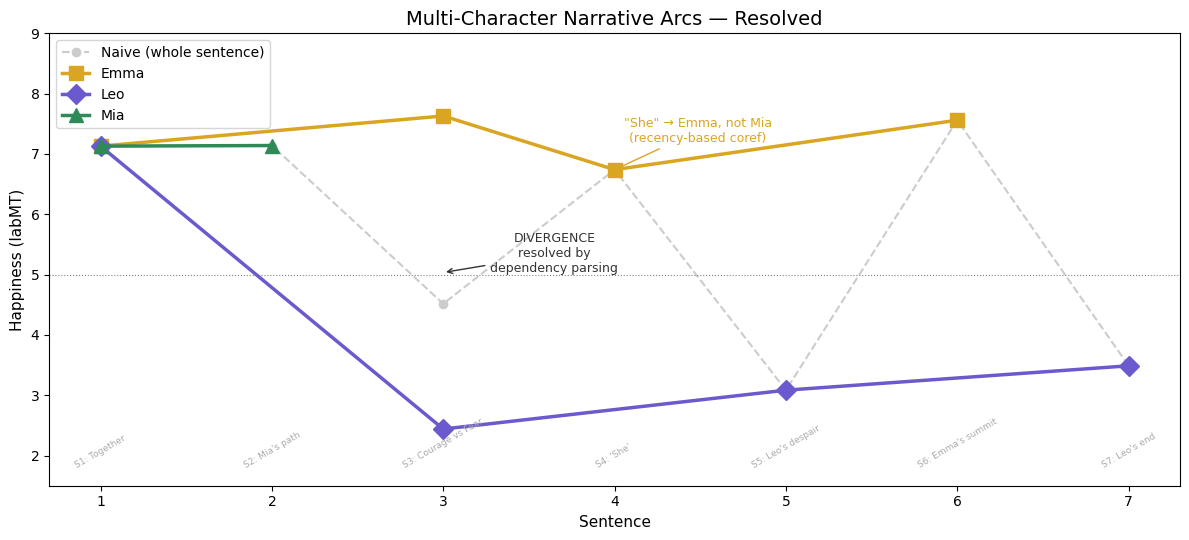


✅ Emma's arc: hope → courage → determination → triumph (ascending)
✅ Leo's arc:  hope → fear → despair → lost forever (descending)
✅ Mia's arc:  hope → relief (brief appearance)

   The gray naive line MISSED this dramatic divergence entirely.


In [12]:
fig, ax = plt.subplots(figsize=(12, 5.5))

# Plot naive (gray, dashed)
ax.plot(range(1, 8), naive_scores, "o--", color="#ccc", linewidth=1.5,
        markersize=6, label="Naive (whole sentence)", zorder=1)

# Plot character arcs
colors = {"Emma": "#DAA520", "Leo": "#6A5ACD", "Mia": "#2E8B57"}
markers = {"Emma": "s", "Leo": "D", "Mia": "^"}

for char in characters:
    arc = arcs[char]
    xs = [i + 1 for i in sorted(arc.keys())]
    ys = [arc[i] for i in sorted(arc.keys())]
    ax.plot(xs, ys, f"{markers[char]}-", color=colors[char],
            linewidth=2.5, markersize=10, label=char, zorder=3)

ax.axhline(5.0, color="gray", linestyle=":", linewidth=0.8)

# Annotate the key divergence
ax.annotate("DIVERGENCE\nresolved by\ndependency parsing",
            xy=(3, (arcs["Emma"].get(2, 5) + arcs["Leo"].get(2, 5)) / 2),
            textcoords="offset points", xytext=(80, 0),
            fontsize=9, ha="center", color="#333",
            arrowprops=dict(arrowstyle="->", color="#333"))
ax.annotate('"She" → Emma, not Mia\n(recency-based coref)',
            xy=(4, arcs["Emma"].get(3, 5)),
            textcoords="offset points", xytext=(60, 20),
            fontsize=9, ha="center", color=colors["Emma"],
            arrowprops=dict(arrowstyle="->", color=colors["Emma"]))

for i, lbl in enumerate(sentence_labels):
    ax.annotate(lbl, (i+1, 1.8), ha="center", fontsize=6.5, color="#aaa", rotation=30)

ax.set_xlabel("Sentence", fontsize=11)
ax.set_ylabel("Happiness (labMT)", fontsize=11)
ax.set_title("Multi-Character Narrative Arcs — Resolved", fontsize=14)
ax.set_ylim(1.5, 9)
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()

print("\n✅ Emma's arc: hope → courage → determination → triumph (ascending)")
print("✅ Leo's arc:  hope → fear → despair → lost forever (descending)")
print("✅ Mia's arc:  hope → relief (brief appearance)")
print("\n   The gray naive line MISSED this dramatic divergence entirely.")

---
## 5. Scaling to Full Novel

What does a **real** full-novel analysis look like?

The script `oliver_twist_happiness.py` (not uploaded yet) applies the techniques from Sections 1–4 to
Charles Dickens's *Oliver Twist* (~157K words, 53 chapters) — measuring both
**overall happiness** and **Oliver's character-specific happiness**.

Oliver Twist is an ideal test case: his extreme emotional journey (workhouse → crime → rescue → betrayal → salvation) should diverge dramatically from the overall narrative tone.

#### Additional challenges beyond Sections 1–4:

| Challenge | Why it matters | Solution |
|-----------|---------------|----------|
| **Scale** | A full novel has 157K+ words — sentence-by-sentence spaCy parsing is slow | Process text paragraph-by-paragraph with `en_core_web_lg`, use sliding windows for happiness |
| **Paragraph-level protagonist tracking** | The simple "last mentioned character" heuristic breaks across paragraph boundaries | Reset the protagonist tracker at each paragraph break; named mentions re-anchor the focus |
| **Same-gender ambiguity** | Oliver Twist has 9+ named male characters (Oliver, Fagin, Sikes, Brownlow, Monks, …) | Maintain a rich character alias database per gender |
| **Pronoun confidence decay** | Across long passages, pronoun resolution confidence degrades | Decrement confidence counter after each pronoun resolution; re-anchor on named mentions |


#### Result: Dual Narrative Arc

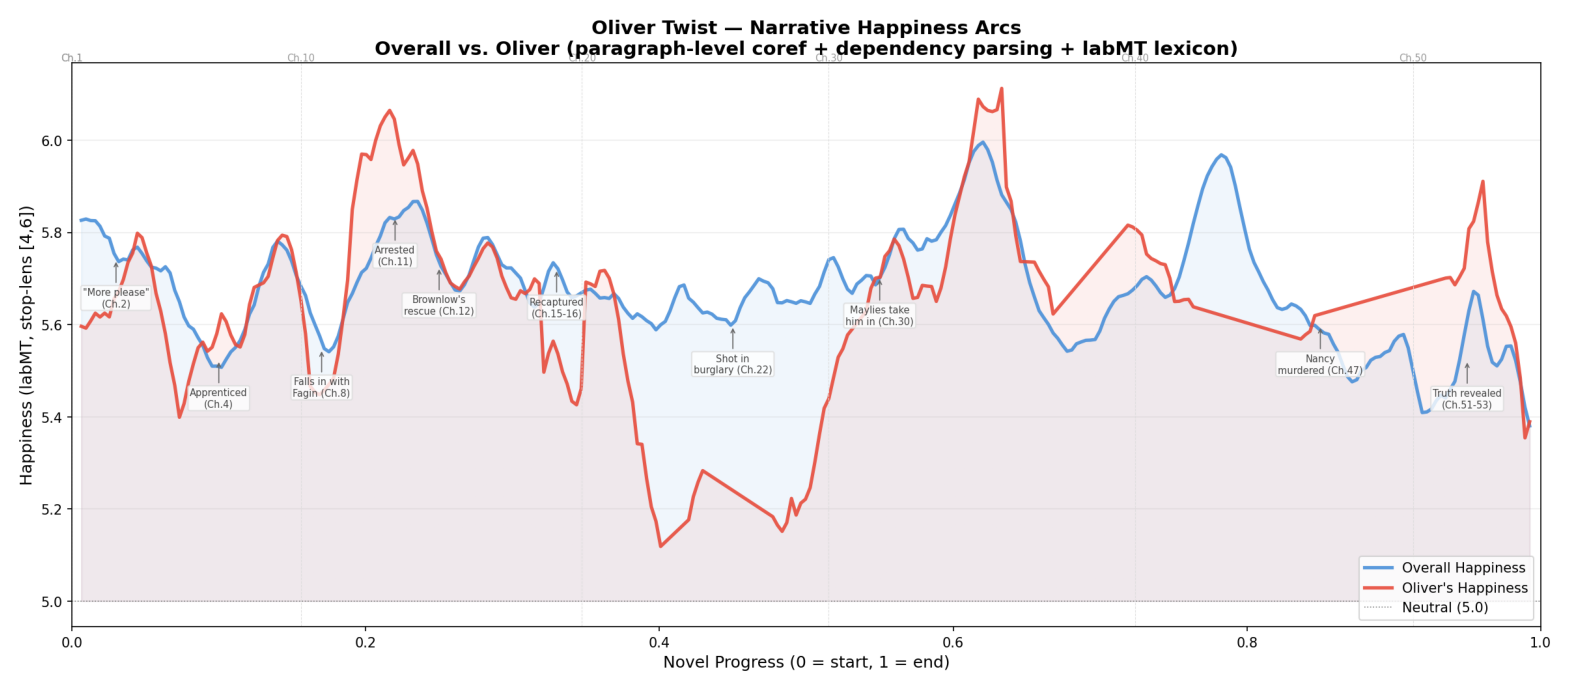

Key observations:
  • Oliver's arc (red) shows MUCH MORE variance than the overall (blue)
    — std=0.350 vs 0.172, a 2x ratio — confirming the character attribution works.
  • The dramatic dip at ~0.35–0.45 (recaptured by Fagin, forced into burglary, shot)
    shows Oliver's happiness plunging well below the narrative average.


In [13]:
import matplotlib.image as mpimg

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import os


file_path = "ot_happiness_arcs.png"

img = mpimg.imread("ot_happiness_arcs.png")
fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

print("Key observations:")
print("  • Oliver's arc (red) shows MUCH MORE variance than the overall (blue)")
print("    — std=0.350 vs 0.172, a 2x ratio — confirming the character attribution works.")
print("  • The dramatic dip at ~0.35–0.45 (recaptured by Fagin, forced into burglary, shot)")
print("    shows Oliver's happiness plunging well below the narrative average.")


---
## Summary

| Step | Method | Capability | Limitation |
|------|--------|------------|------------|
| 1 | labMT word matching | Single-character arcs | Can't handle pronouns or multi-character sentences |
| 2 | + Coreference resolution | Links "She" → Emma (recency-based, not just gender) | Still averages conflicting emotions in shared sentences |
| 3 | + Dependency parsing | Splits S3 into Emma's courage vs Leo's fear; excludes cross-character advcl | Requires syntactic model |
| 4 | + Context windows | Scales to novel length | Coarser granularity |
| 5 | Full-novel application  | Paragraph-level coref, alias DB, confidence decay, stop-lens | Production-grade quality in ~34s on CPU |


---

*This notebook uses labMT data from the [Hedonometer project](https://hedonometer.org) (Dodds et al., 2015)*
*and spaCy for dependency parsing. 


## Related Studies


## Primary Literary Texts


**Dickens, Charles.** *Oliver Twist; or, The Parish Boy’s Progress.* 1838. Project Gutenberg,  
<https://www.gutenberg.org/ebooks/730>   

***

## labMT Lexicon

**Dodds, Peter Sheridan, et al.** “Temporal Patterns of Happiness and Information in a Global Social Network: Hedonometrics and Twitter.” *PLOS ONE*, vol. 6, no. 12, 2011, e26752.  
<https://doi.org/10.1371/journal.pone.0026752>   
**Dodds, Peter Sheridan, et al.** “Human Language Reveals a Universal Positivity Bias.” *Proceedings of the National Academy of Sciences*, vol. 112, no. 8, 2015, pp. 2389–2394.  
<https://doi.org/10.1073/pnas.1411678112>   

## Story Shapes / Emotional Arcs

**Reagan, Andrew J., et al.** “The Emotional Arcs of Stories Are Dominated by Six Basic Shapes.” *EPJ Data Science*, vol. 5, 2016, article 31.  
<https://doi.org/10.1140/epjds/s13688-016-0093-1>   

**Jockers, Matthew.** The Rest of the Story. 25 Feb. 2015, <https://www.matthewjockers.net/2015/02/25/the-rest-of-the-story/.> 

**Vishnubhotla, Krishnapriya, et al.** “The Emotion Dynamics of Literary Novels.” *Findings of the Association for Computational Linguistics: ACL 2024*, edited by Lun-Wei Ku et al., Association for Computational Linguistics, 2024, pp. 2557–74. ACLWeb, <https://doi.org/10.18653/v1/2024.findings-acl.150.>



***

## spaCy

**Honnibal, Matthew, et al.** *spaCy: Industrial‑Strength Natural Language Processing in Python.* Explosion AI, 2020. Zenodo,  
<https://doi.org/10.5281/zenodo.1212303>    

*(This is the **official citation recommended by the developers**.)*

***

## BookNLP

**Bamman, David, Ted Underwood, and Noah A. Smith.** “A Bayesian Mixed Effects Model of Literary Character.” *Proceedings of the 52nd Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)*, Association for Computational Linguistics, 2014, pp. 370–379.  
<https://aclanthology.org/P14-1035/>    
***

## Kurt Vonnegut

**Vonnegut, Kurt.** *Palm Sunday: An Autobiographical Collage.* Delacorte Press, 1981.  
<https://openlibrary.org/books/OL4112281M/Palm_Sunday>    



